In [1]:
# linear regression model
# predicting sales given TV prices


# neural network to the same linear regression model
# train the network
# implementing the gradient descent method

# increase the complexity of the network
# build a multiple linear regression model
# predicting house prices based on their size and quality

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


np.random.seed(3)

## 1 - Simple Linear Regression

In [4]:
# the general methodology to build a neural network

# 1. define the structure (input units, hidden units)
# 2. initilize the model's parameters
# 3. loop:
#    * forward propagation
#    * backward propagation
#    * update parameters
# 4. make predictions

In [27]:
adv = pd.read_csv("tvmarketing.csv")
adv.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [7]:
# norm the data
adv_norm = (adv - np.mean(adv))/np.std(adv)

/Users/tungliew/opt/miniconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3462: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


<AxesSubplot:xlabel='TV', ylabel='Sales'>

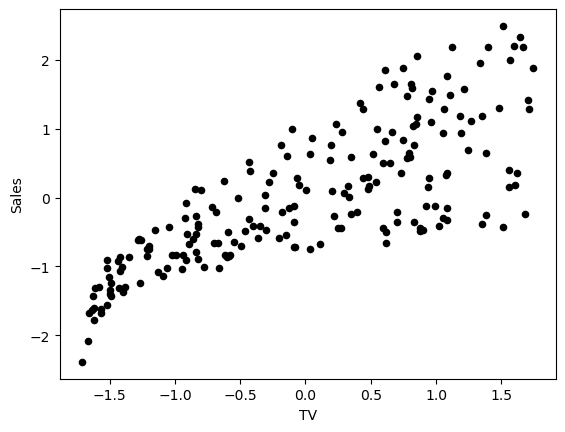

In [28]:
adv_norm.plot(x='TV', y='Sales', kind='scatter', c='black')

In [29]:
X_norm = adv_norm['TV']
Y_norm = adv_norm['Sales']

X_norm = np.array(X_norm).reshape(1, len(X_norm))
Y_norm = np.array(Y_norm).reshape(1, len(Y_norm))

print ('The shape of X_norm: ' + str(X_norm.shape))
print ('The shape of Y_norm: ' + str(Y_norm.shape))
print ('I have m = %d training examples!' % (X_norm.shape[1]))

The shape of X_norm: (1, 200)
The shape of Y_norm: (1, 200)
I have m = 200 training examples!


## 2 - Neural Network Model for Linear Regression

In [10]:
print(X_norm.shape[0])
print(Y_norm.shape[0])

1
1


In [30]:
# n_x: size of input layer
# n_y: size of output layer

def layer_sizes(X,Y):
    n_x = X.shape[0]
    n_y = Y.shape[0]
    
    return (n_x, n_y)

(n_x, n_y) = layer_sizes(X_norm, Y_norm)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 1
The size of the output layer is: n_y = 1


In [31]:
def initialize_parameters(n_x, n_y):
    W = np.random.randn(n_y, n_x) * 0.01
    b = np.zeros((n_y, 1))
    
    parameters = {"W": W,
                  "b": b}
    
    return parameters

parameters = initialize_parameters(n_x, n_y)
print("W = " + str(parameters["W"]))
print("b = " + str(parameters["b"]))

W = [[-0.00354759]]
b = [[0.]]


In [32]:
def forward_propagation(X, parameters):
    W = parameters["W"]
    b = parameters["b"]
    
    Z = np.matmul(W, X) + b
    Y_hat = Z
    
    return Y_hat

Y_hat = forward_propagation(X_norm, parameters)

print("Some elements of output vector Y_hat:", Y_hat[0, 0:5])

Some elements of output vector Y_hat: [-0.00344064  0.0042478   0.0053787  -0.00018465 -0.0013984 ]


In [15]:
print(X_norm.shape)

(1, 200)


In [16]:
print(Y_hat.shape)

(1, 200)


In [33]:
def compute_cost(Y_hat, Y):
    m = Y_hat.shape[1]
    cost = np.sum((Y_hat - Y)**2) / (2*m)
    
    return cost

print("cost = " + str(compute_cost(Y_hat, Y_norm)))

cost = 0.5027813040819005


In [34]:
def backward_propagation(Y_hat, X, Y):
    m = X.shape[1]
    
    # Backward propagation: calculate partial derivatives denoted as dW, db for simplicity. 
    dZ = Y_hat - Y
    dW = 1/m * np.dot(dZ, X.T)
    db = 1/m * np.sum(dZ, axis = 1, keepdims = True)
    
    grads = {"dW": dW,
             "db": db}
    
    return grads


grads = backward_propagation(Y_hat, X_norm, Y_norm)

print("dW = " + str(grads["dW"]))
print("db = " + str(grads["db"]))

dW = [[-0.78577201]]
db = [[1.687539e-16]]


In [35]:
def update_parameters(parameters, grads, learning_rate=1.2):
    W = parameters['W']
    b = parameters['b']
    
    dW = grads['dW']
    db = grads['db']
    
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    parameters = {"W": W,
                  "b": b}
    
    return parameters

parameters_updated = update_parameters(parameters, grads)

print("W updated = " + str(parameters_updated["W"]))
print("b updated = " + str(parameters_updated["b"]))

W updated = [[0.93937883]]
b updated = [[-2.0250468e-16]]


In [36]:
# itegration and predictions
def nn_model(X, Y, num_iterations=10, learning_rate=1.2, print_cost=False):
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[1]
    
    parameters = initialize_parameters(n_x, n_y)
    
    # loop
    for i in range(num_iterations):
        Y_hat = forward_propagation(X, parameters)
        
        cost = compute_cost(Y_hat, Y)
        
        grads = backward_propagation(Y_hat, X, Y)
        
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if print_cost:
            print ("Cost after iteration %i: %f" %(i, cost))
            
    
    return parameters

In [37]:
parameters_simple = nn_model(X_norm, Y_norm, num_iterations=30, learning_rate=1.2, print_cost=True)
print("W = " + str(parameters_simple["W"]))
print("b = " + str(parameters_simple["b"]))

W_simple = parameters["W"]
b_simple = parameters["b"]

Cost after iteration 0: 0.500648
Cost after iteration 1: 0.206326
Cost after iteration 2: 0.194553
Cost after iteration 3: 0.194082
Cost after iteration 4: 0.194063
Cost after iteration 5: 0.194063
Cost after iteration 6: 0.194062
Cost after iteration 7: 0.194062
Cost after iteration 8: 0.194062
Cost after iteration 9: 0.194062
Cost after iteration 10: 0.194062
Cost after iteration 11: 0.194062
Cost after iteration 12: 0.194062
Cost after iteration 13: 0.194062
Cost after iteration 14: 0.194062
Cost after iteration 15: 0.194062
Cost after iteration 16: 0.194062
Cost after iteration 17: 0.194062
Cost after iteration 18: 0.194062
Cost after iteration 19: 0.194062
Cost after iteration 20: 0.194062
Cost after iteration 21: 0.194062
Cost after iteration 22: 0.194062
Cost after iteration 23: 0.194062
Cost after iteration 24: 0.194062
Cost after iteration 25: 0.194062
Cost after iteration 26: 0.194062
Cost after iteration 27: 0.194062
Cost after iteration 28: 0.194062
Cost after iteration 29:

In [38]:
def predict(X, Y, parameters, X_pred):
    
    # Retrieve each parameter from the dictionary "parameters".
    W = parameters["W"]
    b = parameters["b"]
    
    # Use the same mean and standard deviation of the original training array X.
    if isinstance(X, pd.Series):
        X_mean = np.mean(X)
        X_std = np.std(X)
        X_pred_norm = ((X_pred - X_mean)/X_std).reshape((1, len(X_pred)))
    else:
        X_mean = np.array(np.mean(X)).reshape((len(X.axes[1]),1))
        X_std = np.array(np.std(X)).reshape((len(X.axes[1]),1))
        X_pred_norm = ((X_pred - X_mean)/X_std)
    # Make predictions.
    Y_pred_norm = np.matmul(W, X_pred_norm) + b
    # Use the same mean and standard deviation of the original training array Y.
    Y_pred = Y_pred_norm * np.std(Y) + np.mean(Y)
    
    return Y_pred[0]

X_pred = np.array([50, 120, 280])
Y_pred = predict(adv["TV"], adv["Sales"], parameters_simple, X_pred)
print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales:\n{Y_pred}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales:
[ 9.40942557 12.7369904  20.34285287]


In [40]:
# neural network model
# single perceptron
# two input nodes

## Multiple Linear Regression

In [41]:
df = pd.read_csv("house_prices_train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [42]:
X_multi = df[['GrLivArea', 'OverallQual']]
Y_multi = df['SalePrice']

display(X_multi)
display(Y_multi)

,GrLivArea,OverallQual
0,1710,7
1,1262,6
2,1786,7
3,1717,7
4,2198,8
...,...,...
1455,1647,6
1456,2073,6
1457,2340,7
1458,1078,5


0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [43]:
X_multi_norm = (X_multi - np.mean(X_multi))/np.std(X_multi)
Y_multi_norm = (Y_multi - np.mean(Y_multi))/np.std(Y_multi)

/Users/tungliew/opt/miniconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3462: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [44]:
X_multi_norm = np.array(X_multi_norm).T
Y_multi_norm = np.array(Y_multi_norm).reshape((1, len(Y_multi_norm)))

In [45]:
print(X_multi_norm.shape)
print(Y_multi_norm.shape)

(2, 1460)
(1, 1460)


In [46]:
print ('The shape of X: ' + str(X_multi_norm.shape))
print ('The shape of Y: ' + str(Y_multi_norm.shape))
print ('I have m = %d training examples!' % (X_multi_norm.shape[1]))

The shape of X: (2, 1460)
The shape of Y: (1, 1460)
I have m = 1460 training examples!


In [49]:
# two features
test_a, test_b = layer_sizes(X_multi_norm, Y_multi_norm)
print(test_a)
print(test_b)

2
1
